<a href="https://colab.research.google.com/github/priyanshukum-array/ML_PROJECTS/blob/main/ECG_Arrhythmia_Classification_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ranaprafful/mit-bih")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mit-bih' dataset.
Path to dataset files: /kaggle/input/mit-bih


In [41]:
import os

os.listdir(path)

['mitbih_test.csv', 'mitbih_train.csv']

In [42]:
data = pd.read_csv(
    os.path.join(path, "mitbih_train.csv"), header=None
)

In [43]:
data.shape

(87554, 188)

In [44]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
X=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

In [46]:
X.shape

(87554, 187)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.2416234023837039), 1: np.float64(7.878852643419573), 2: np.float64(3.0256155507559397), 3: np.float64(27.307212475633527), 4: np.float64(2.722759961127308)}


In [49]:
#Classes: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]
np.unique(y)

array([0., 1., 2., 3., 4.])

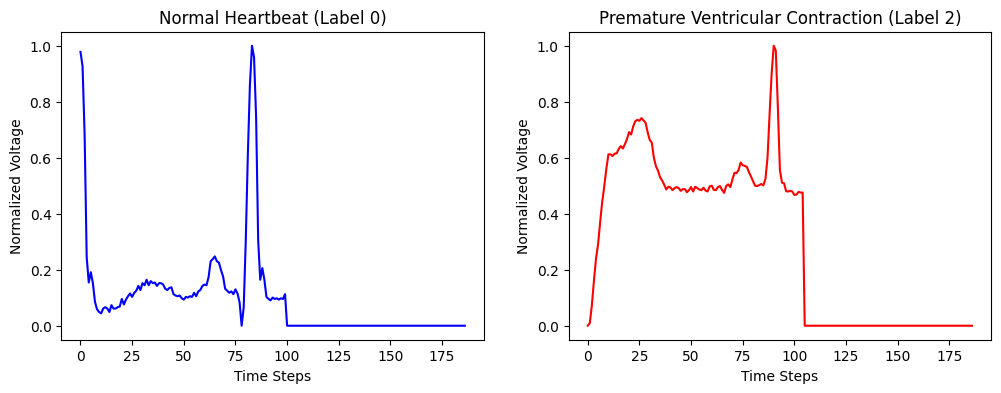

In [50]:
# 2. Find the index of the first Normal beat (Label 0) and first Abnormal beat (e.g., Label 2)
normal_idx = np.where(y == 0)[0][0]
abnormal_idx = np.where(y == 2)[0][0]

# 3. Plot the waveforms
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(X[normal_idx], color='blue')
plt.title("Normal Heartbeat (Label 0)")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Voltage")

plt.subplot(1, 2, 2)
plt.plot(X[abnormal_idx], color='red')
plt.title("Premature Ventricular Contraction (Label 2)")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Voltage")

plt.show()

In [51]:
X = X.reshape( X.shape[0], X.shape[1],1)
print(X.shape)

(87554, 187, 1)


In [52]:
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test=X_test.reshape(X_test.shape[0],X_test.shape[1],1)

In [53]:
X_train.shape

(70043, 187, 1)

In [54]:
X_test.shape

(17511, 187, 1)

building LSTM digitial brain

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [56]:
model = Sequential()

In [57]:
# 1. The LSTM Layer: 64 internal memory units tracking the wave sequence
# input_shape must match our (Time Steps, Features) -> (187, 1)
model.add(LSTM(64, input_shape=(187, 1)))

# 2. Dropout Layer: Randomly turns off 20% of neurons during training to prevent overfitting
model.add(Dropout(0.2))

# 3. Dense Hidden Layer: Integrates the sequential features captured by the LSTM
model.add(Dense(32, activation='relu'))

# 4. Output Layer: 5 nodes representing our 5 heartbeat conditions (0 to 4)
model.add(Dense(5, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [58]:
# Compile the model
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [59]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',          # Watch validation loss
    patience=5,                  # Wait 5 epochs
    restore_best_weights=True    # Restore the best model
)

In [60]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,                  # Increased
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]      # Add this
)

Epoch 1/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2695 - loss: 1.5699 - val_accuracy: 0.0710 - val_loss: 1.6755
Epoch 2/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.0865 - loss: 1.4580 - val_accuracy: 0.0548 - val_loss: 1.4802
Epoch 3/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.0698 - loss: 1.4114 - val_accuracy: 0.0907 - val_loss: 1.5647
Epoch 4/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.0783 - loss: 1.3966 - val_accuracy: 0.0979 - val_loss: 1.5785
Epoch 5/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0864 - loss: 1.3822 - val_accuracy: 0.0964 - val_loss: 1.5326
Epoch 6/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.0952 - loss: 1.3545 - val_accuracy: 0.1034 - val_loss: 1.5746
Epoch 7/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.1008 - loss: 1.3300 - val_accuracy: 0.1108 - val_loss: 1.5451


In [61]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Generate predictions on the 3D test signals
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# 2. Print the final performance metrics
print("--- ECG Diagnostic Report ---")
# Defined target names based on the MIT-BIH class mappings
target_labels = ['Normal', 'Supraventricular', 'Ventricular (PVC)', 'Fusion', 'Unknown']
print(classification_report(y_test, predicted_classes, target_names=target_labels))

548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
--- ECG Diagnostic Report ---
                   precision    recall  f1-score   support

           Normal       0.81      0.00      0.01     14494
 Supraventricular       0.00      0.00      0.00       445
Ventricular (PVC)       0.11      0.57      0.19      1158
           Fusion       0.01      0.95      0.03       128
          Unknown       0.05      0.09      0.07      1286

         accuracy                           0.06     17511
        macro avg       0.20      0.32      0.06     17511
     weighted avg       0.69      0.06      0.03     17511



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [62]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0553 - loss: 1.4805
Test Loss: 1.4804812669754028
Test Accuracy: 0.05533664673566818


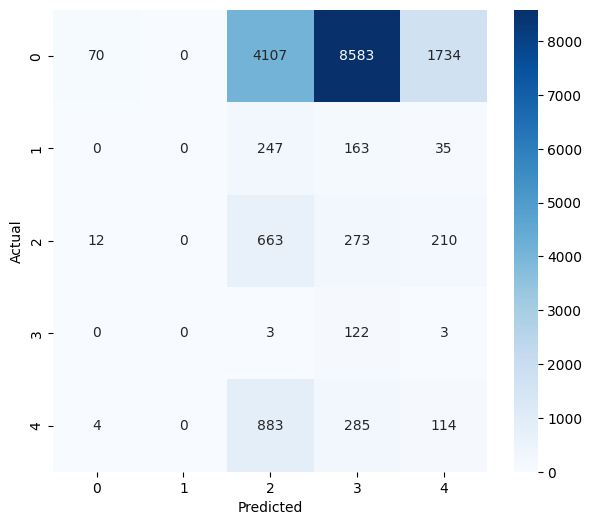

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,425 (224.32 KB)

 Trainable params: 19,141 (74.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,284 (149.55 KB)

In [65]:
print(class_weights)

{0: np.float64(0.2416234023837039), 1: np.float64(7.878852643419573), 2: np.float64(3.0256155507559397), 3: np.float64(27.307212475633527), 4: np.float64(2.722759961127308)}


In [66]:
pred = model.predict(X_test)
pred = np.argmax(pred, axis=1)

print(np.bincount(pred))

548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
[  86    0 5903 9426 2096]
